# **Step1. 상품 리뷰 감성 분류**

**미션 : 리뷰마다 긍/부정 감성분석하기**
1) 목표 : 리뷰를 긍, 부정으로 분류하는 모델 생성
사전학습 모델을 파인 튜닝하여 모델 성능 높이기
2) 절차
    * 데이터 전처리
        - 긍/부정 분류를 위한 데이터셋 구성
        - 데이터 불균형 문제 해결하기
    * 사전학습 모델 파인 튜닝 : klue/bert-base 사용 권장
3) 최소 4가지 이상의 실험을 구성하고 수행하고 성능 비교
    * 학습 + 검증 데이터 : 10만 건 중 일부를 샘플링해서 수행.
    * 모델링 : 일반 파인튜닝, LoRA 파인튜닝 적용
    * 하이퍼파라미터 조정


## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [ ]:
!pip install datasets peft accelerate -q

* 설치 후 세션 다시 시작

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

from peft import get_peft_model, LoraConfig, TaskType

from warnings import filterwarnings
FutureWarning
filterwarnings('ignore')

* 함수 생성

In [ ]:
# 검증셋 평가 함수
def evaluate(val_ds, model, device, tokenizer):
    # 입력 데이터셋 토크나이징 (attention_mask 포함)
    inputs = tokenizer(list(val_ds['text']), return_tensors="pt", padding=True,
                       truncation=True, max_length=128
    )
    inputs = {key: value.to(device) for key, value in inputs.items()}  # 입력 텐서를 동일한 디바이스로 이동

    # 모델을 지정된 디바이스로 이동
    model = model.to(device)

    with torch.no_grad():  # 평가 과정에서 기울기 계산 비활성화
        outputs = model(**inputs)  # attention_mask를 포함해 입력

    # 예측 및 확률 계산
    probabilities = outputs.logits.softmax(dim=1)

    # probabilities가 GPU에 있을 경우에만 CPU로 이동
    if probabilities.is_cuda:
        probabilities = probabilities.cpu().detach().numpy()
    else:
        probabilities = probabilities.detach().numpy()

    pred = np.argmax(probabilities, axis=1)

    # GPU 메모리에서 필요 없는 텐서 제거 및 캐시 정리
    del inputs
    torch.cuda.empty_cache()

    return pred, probabilities

In [ ]:
def predict(text, model, tokenizer):
    # 모델을 CPU로 이동
    model = model.to("cpu")

    # 입력 문장 토크나이징 → CPU 텐서로 생성
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    # 모델 예측 (no_grad로 메모리 절약)
    with torch.no_grad():
        outputs = model(**inputs)

    # 확률 계산
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=1)

    # 예측 클래스
    pred = torch.argmax(probabilities, dim=-1).item()

    return pred, probabilities


### (2) GPU 설정
* GPU 사용을 위한 설정

In [ ]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

## 2.데이터 준비① : 데이터 구조 만들기
* 아래와 같은 형태로 데이터 셋을 준비합니다.
    * 하나의 리뷰 문장에 하나의 긍/부정 값 지정
    * 리뷰별 label의 평균 값 >= 0.5 ➔ 긍정(1)

* 데이터 불균형을 확인하고 조치합니다.

### (1) 데이터 불러오기
* 제공 받은 'data.csv' 파일을 불러 옵니다.

In [ ]:
# 파일 업로드
from google.colab import files
uploaded = files.upload()

### (2) 데이터 구조 만들기

* 다음과 같은 형태로 리뷰별 데이터 구조를 만듭니다.

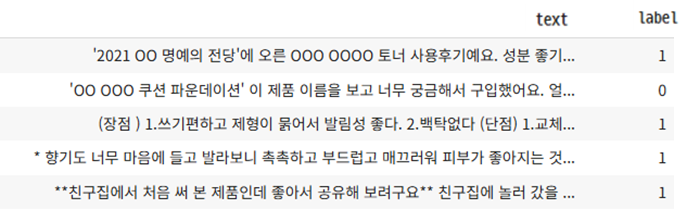

### (3) 데이터 불균형 해결하기

* label의 분포 확인하기

* label이 0과 1인 인 경우 각각 샘플링 2000건씩
    * 더 많이 할 수도 있지만 학습 시간을 고려


In [ ]:
# 데이터 샘플링


In [ ]:
# 데이터 분포 다시 확인


## 3.데이터 준비② : 데이터 전처리

### (1) Dataset 만들기 : train, val
* train_test_split 함수 이용

* 텐서 데이터셋 만들기

### (2) 토크나이징
* 모델 : "klue/bert-base"

In [ ]:
# 모델과 토크나이저 불러오기


In [ ]:
# 토큰화 함수 생성 및 작업


## 4.Fine-Tuning ①
* 일반 파인 튜닝 수행

### (1) 사전학습 모델 준비

In [ ]:
# 모델 로드


### (2) 학습 설정

In [ ]:
# TrainingArguments 설정


In [ ]:
# Trainer 설정


### (3) 학습

### (4) 모델 검증평가

## 5.Fine-Tuning②
* LoRA(Low-Rank Adaptation)

### (1) 사전학습 모델 준비
* 위에서 적용한 내용

In [ ]:
# 모델 로드


### (2) LoRA 구성

In [ ]:
# LoRA 구성 정의


# LoRA 적용 (일부 레이어만 학습)



### (3) 학습

In [ ]:
# TrainingArguments 설정


# Trainer 설정 (compute_metrics, callbacks 등 필요 시 추가)



In [ ]:
# 학습 시작


### (4) 모델 검증평가